In [1]:
%reset -f
import numpy as np
from samplers.SEIR_emcee import SEIR_emcee
from samplers.SEIR_pytwalk import SEIR_pytwalk
from samplers.SEIR_pyhmc import SEIR_pyhmc
from epidemic_model import SEIR_Model
from utils.utils import load_data, parser
import sys
import matplotlib.pyplot as plt
from time import time
from joblib import dump, load

In [2]:
from bokeh.io import output_notebook, show

output_notebook()

Loading BokehJS ...

Data loaded from file:  data/Smoothed_Cases_Third_Wave.csv


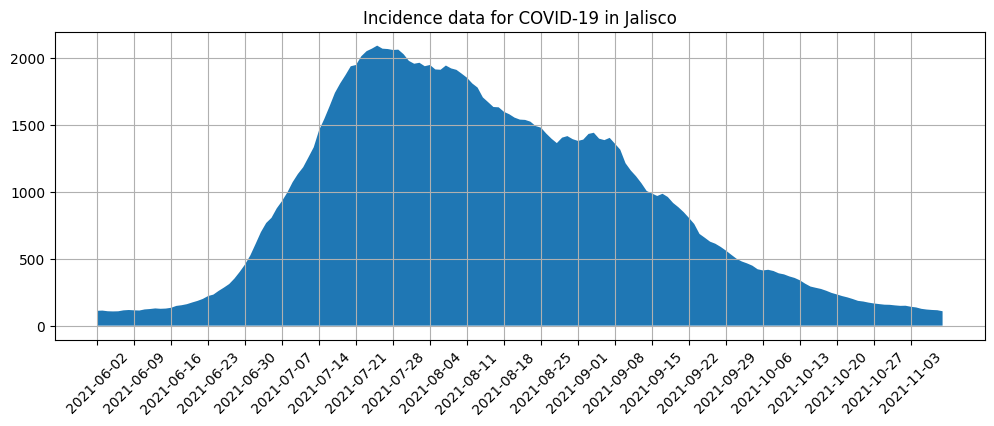

In [3]:
# Loading configuration from configuration file
fname_conf = './configuration_file_test.cfg'

params = parser(fname_conf)

times, data, dates = load_data(params['fname'])

print('Data loaded from file: ', params['fname'])

# plotting data
plt.figure(figsize=(12,4))
plt.fill_between(dates,data, label='Incidence data')
plt.xticks(dates[::7],rotation=45)
plt.title('Incidence data for COVID-19 in Jalisco')
plt.grid()
plt.show()


In [4]:
print(dates[0], dates[-1])
print(np.sum(data))

2021-06-02 2021-11-09
144769.7142857143


In [5]:
# Total population size is taken from the configuration file
N = params["N"]

# Setting initial conditions
E0 = data[0]*5 
I0 = params['I0']
R0 = 0
S0 = N - E0 - I0 - R0

x0 = [S0,E0,I0,R0]

iterations = params['iterations']  # Number of iterations for the MCMC sampler
ndim = 3                           # Dimension of the problem is 3: beta, sigma, gamma

reload_flag = (params['reload'] == 1)
out_file = params['outfile']
outpath = params['outpath']

In [6]:
#### Run this cell in case that are loading a previous run
if reload_flag :
    seir_pyhmc = load(outpath+'/pyhmc/'+out_file)
    seir_pyhmc.outpath = outpath

In [7]:
if not reload_flag :
        seir_pyhmc = SEIR_pyhmc(
                ndim=ndim,
                data=data,
                time=times,
                x0=x0,
                labels=['beta', 'sigma', 'gamma'],
                **params
                )
        
        p0 = np.array([0.35,0.05,0.2])


In [8]:
if not reload_flag :
    ini_time = time()
    seir_pyhmc.run(iterations,p0)
    end_time = time()
    print('Time elapsed: ', end_time-ini_time)

    dump(seir_pyhmc, outpath+'/pyhmc/'+out_file)

In [9]:
print(seir_pyhmc.Output.shape)
print(seir_pyhmc.Outputp.shape)

(15001, 4)
(15001, 4)


In [10]:
#seir_pyhmc.instance = 'pyhmc'
seir_pyhmc.create_dictionary()

In [11]:
seir_pyhmc.summary()


        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
beta   0.357  0.009   0.344    0.376      0.005    0.001       6.0      29.0   
sigma  0.040  0.009   0.031    0.053      0.005    0.001       6.0      31.0   
gamma  0.014  0.038   0.000    0.031      0.001    0.009     894.0     858.0   

       r_hat  
beta    1.30  
sigma   1.49  
gamma   1.00  


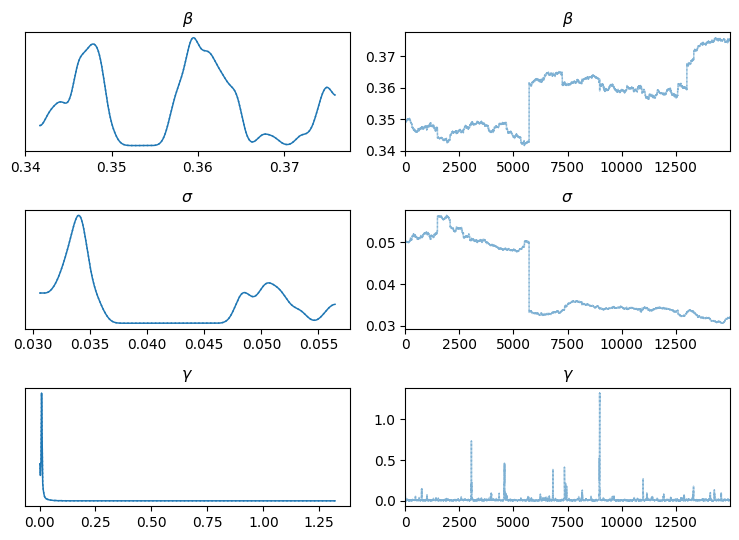

In [18]:

#seir_pyhmc.report_results()
seir_pyhmc.plot_trace()

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
beta   0.364  0.006   0.358    0.375      0.002    0.002      13.0      33.0   
sigma  0.034  0.001   0.031    0.036      0.000    0.000       7.0      39.0   
gamma  0.014  0.038   0.000    0.034      0.002    0.011     467.0     547.0   

       r_hat  
beta    1.36  
sigma   1.23  
gamma   1.00  


<Figure size 640x480 with 0 Axes>

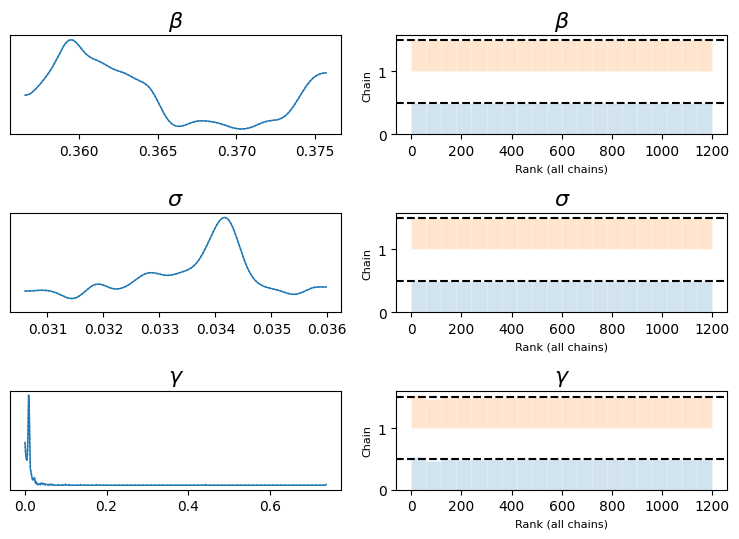

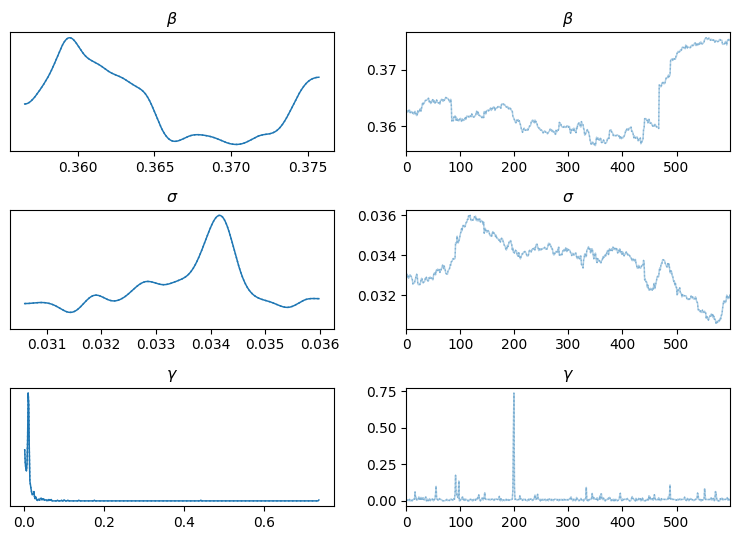

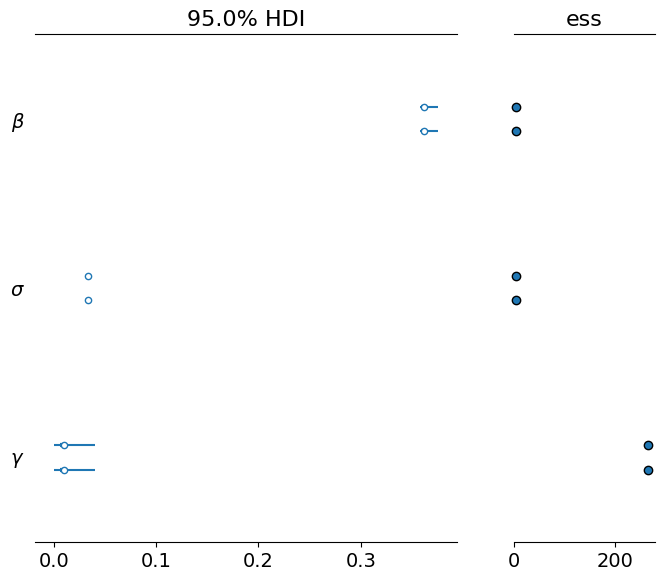

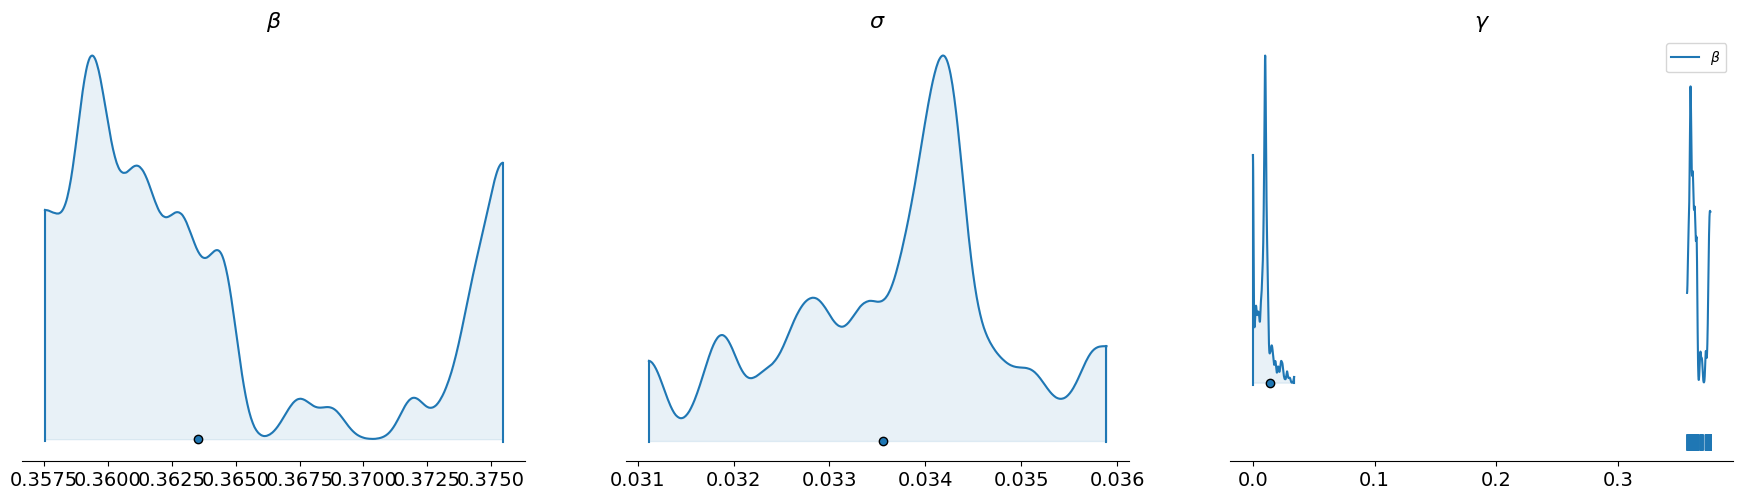

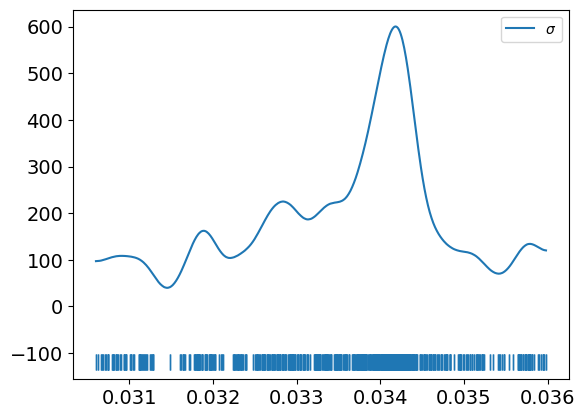

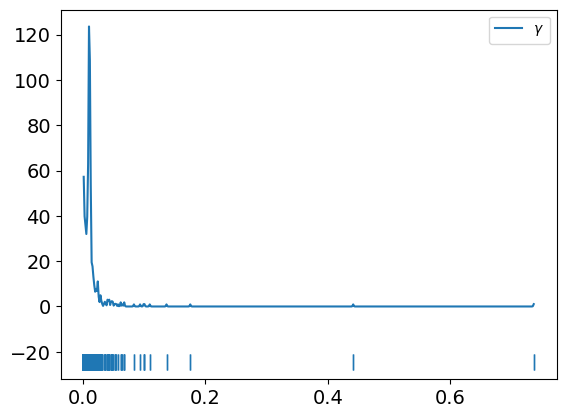

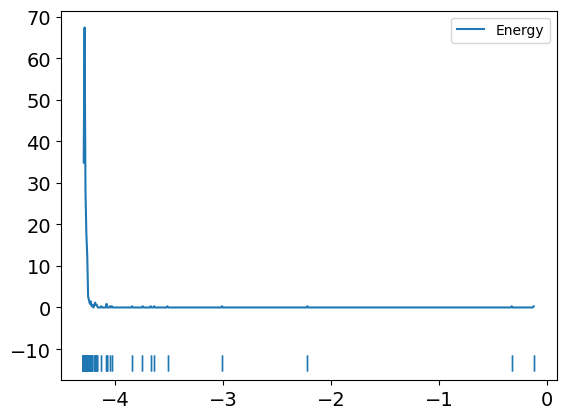

Generating 10 prior samples. Prior model: Gamma
Generating prior curves. Prior model: Gamma


/home/abel/seir_uq_methods/utils/AnalysisTools.py:295: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_yticklabels(ax[i,j].get_yticklabels(), fontsize=10)
/home/abel/seir_uq_methods/utils/AnalysisTools.py:296: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_xticklabels(ax[i,j].get_xticklabels(), fontsize=10)
/home/abel/seir_uq_methods/utils/AnalysisTools.py:295: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_yticklabels(ax[i,j].get_yticklabels(), fontsize=10)
/home/abel/seir_uq_methods/utils/AnalysisTools.py:296: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_xticklabels(ax[i,j].get_xticklabels(), fontsize=10)
/hom

Using 300 samples


100%|██████████| 600/600 [00:09<00:00, 61.25it/s]


RMSE mean: 272.5132018080185
RMSE median: 291.6729264122583
RMSE MAP: 333.97336366785487
Coverage of the 25%-75% credible interval: 0.24
Coverage of the 2.5%-97_5% credible interval: 0.63


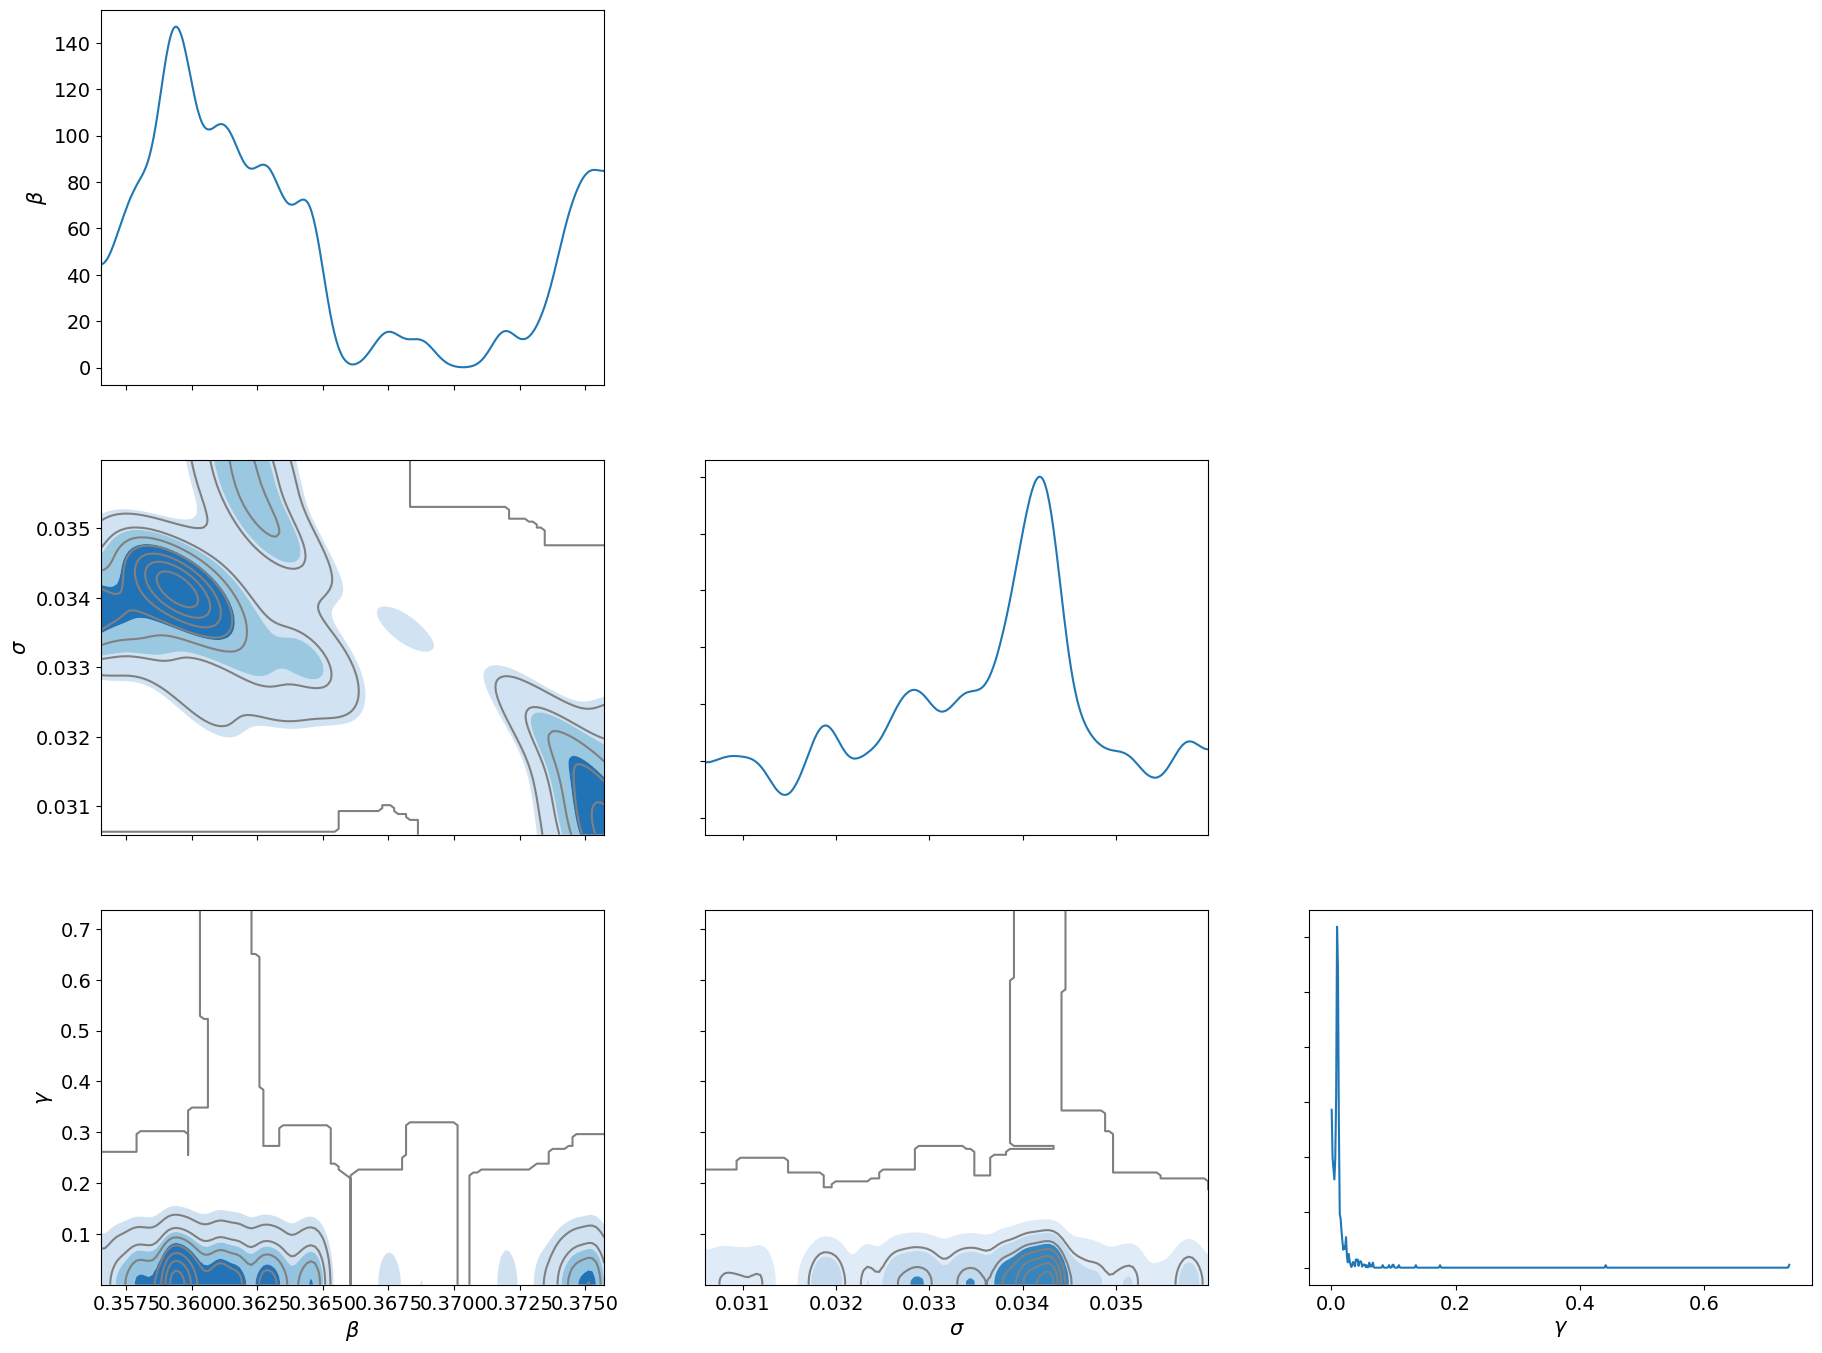

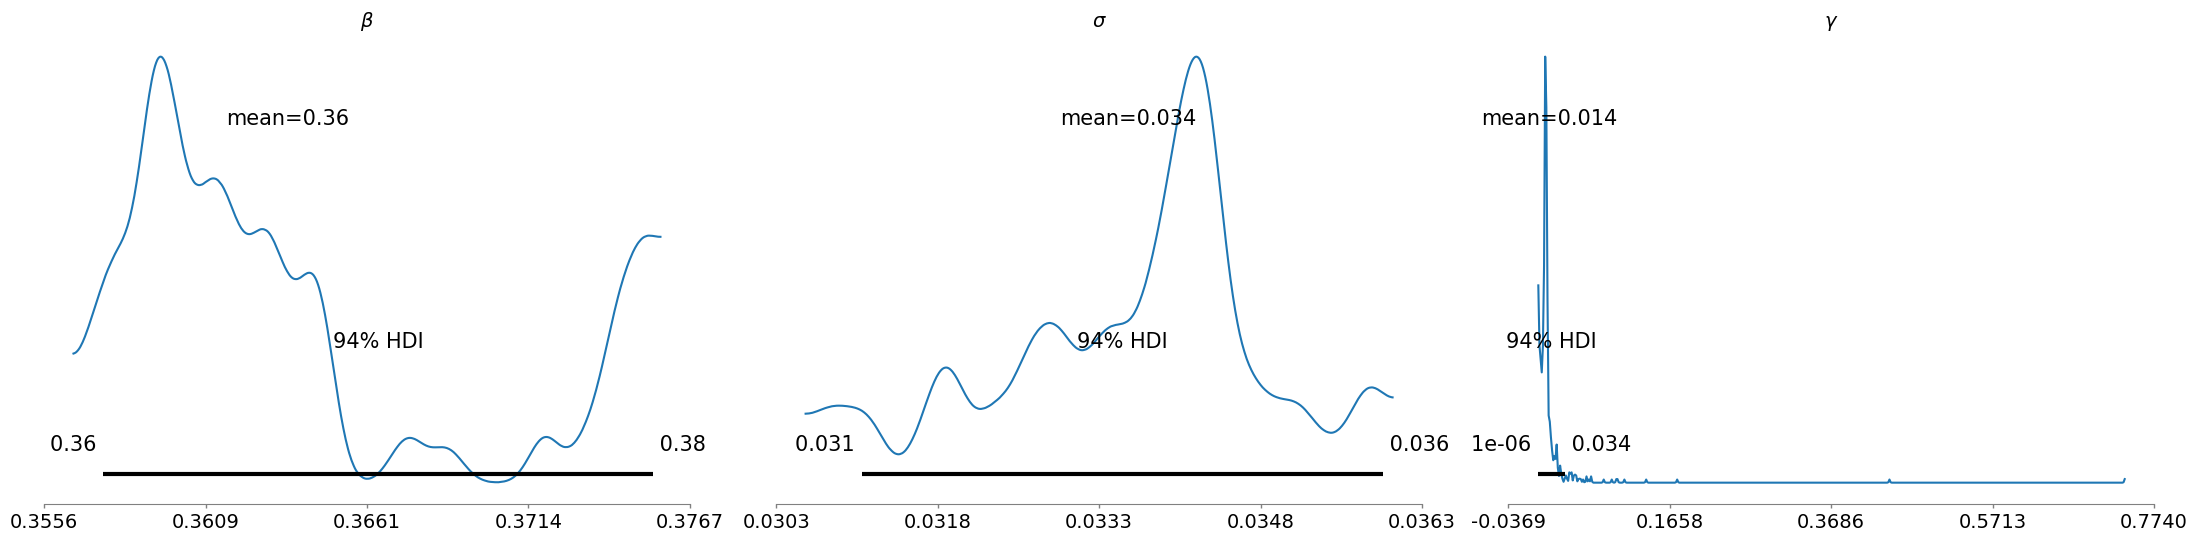

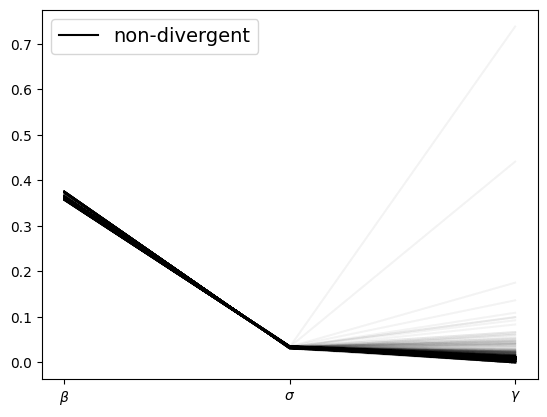

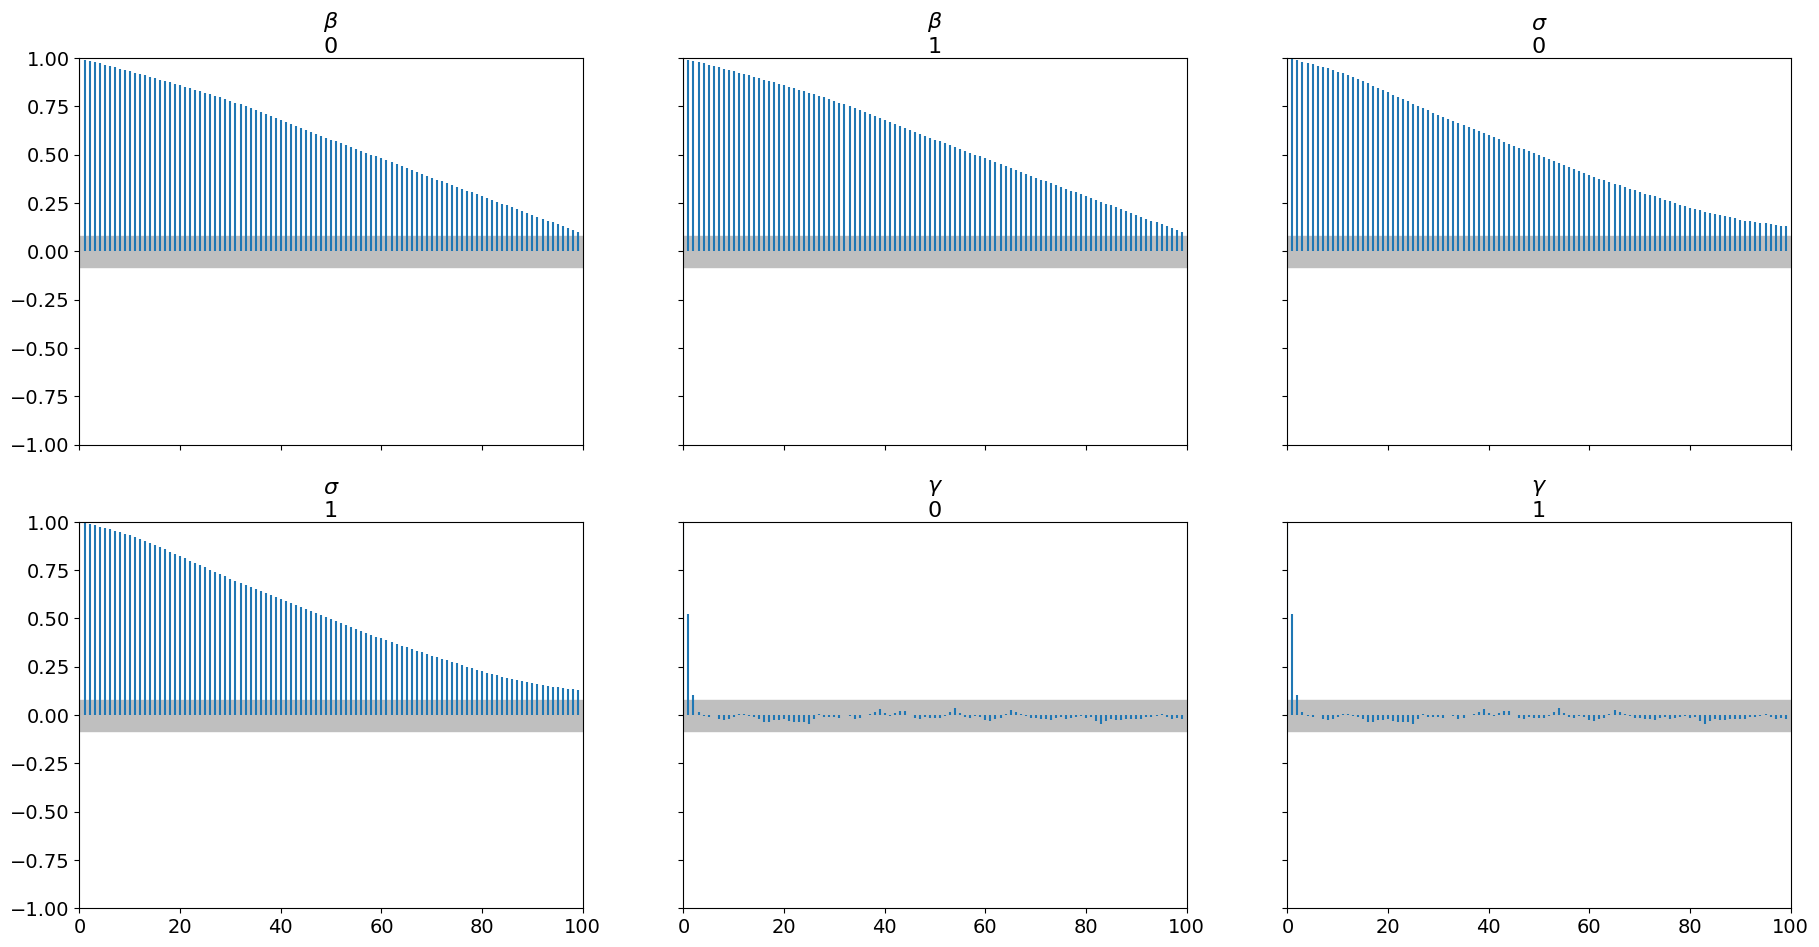

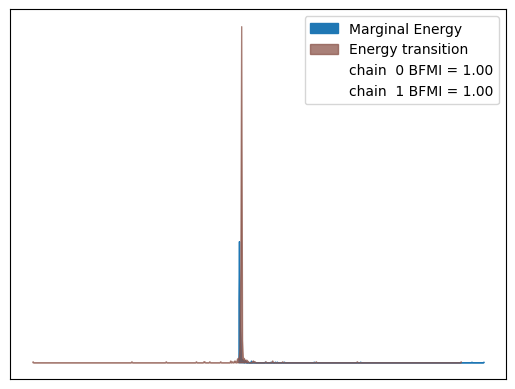

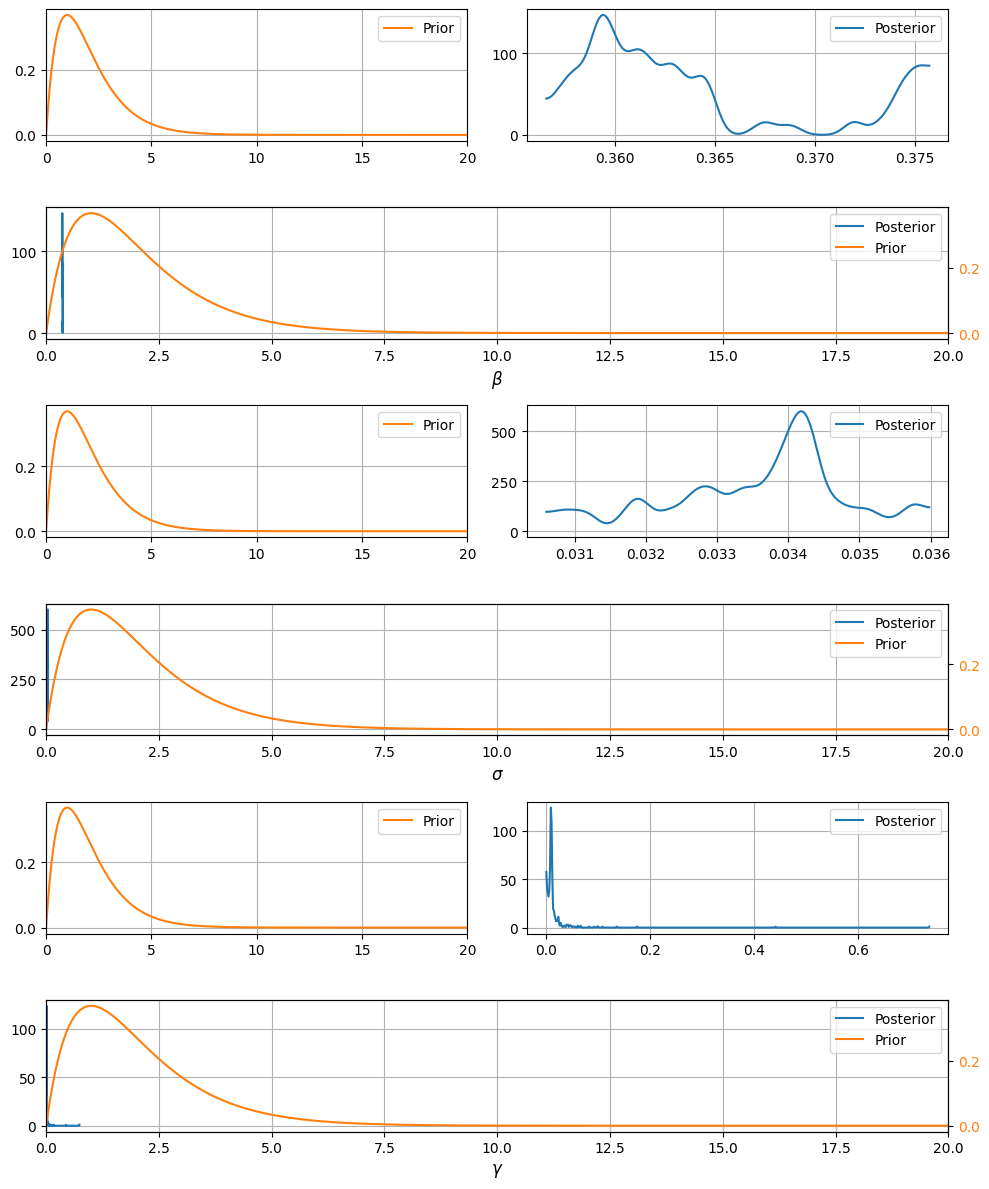

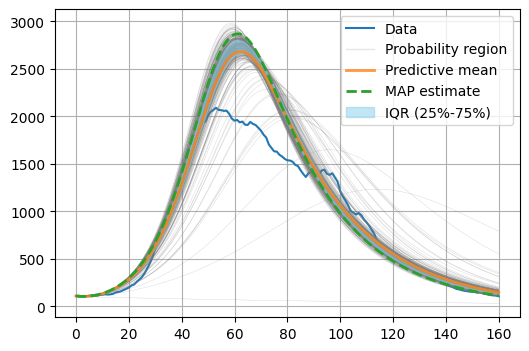

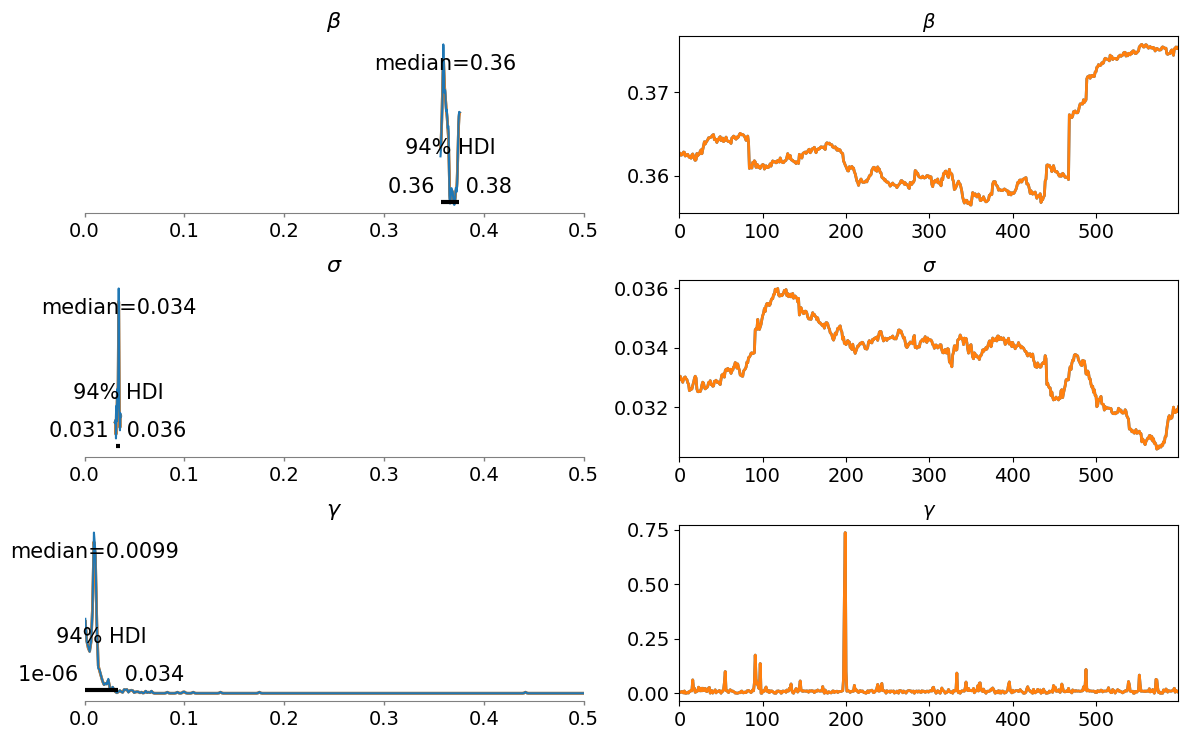

In [12]:
seir_pyhmc.create_dictionary(burnin=6000, subsample=15)

seir_pyhmc.report_results()